In [1]:
# ============================================================
# NOTEBOOK 3: SeCSi-GAN Student Multi-Input Classifier
# Runtime: TPU (recommended) or GPU
#
# Inputs required (add as Kaggle dataset inputs):
#   1. Your bladder tissue image dataset
#   2. Your splits dataset (CSVs from data preparation)
#   3. Notebook 1 output (G_AB_final.h5, G_BA_final.h5)
#   4. Notebook 2 output (teacher_best.h5, nbi_pseudo_labels.csv)
#
# Outputs:
#   student_best.h5
#   student_final.h5
#   student_training_log.csv
#   student_cm_*.png
#   student_training_curves.png
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet101
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             cohen_kappa_score,
                             matthews_corrcoef)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

# ============================================================
# CONFIG
# ============================================================

class CFG:
    # --- Paths ---
    DATASET_PATH  = "/kaggle/input/datasets/aryashah2k/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue"
    SPLITS_PATH   = "/kaggle/input/datasets/kathan1803/ebt-research-processed-data"
    GAN_PATH      = "/kaggle/input/datasets/kathan1803/gansteacher-network-weights-and-pseudo-labels"
    TEACHER_PATH  = "/kaggle/input/datasets/kathan1803/gansteacher-network-weights-and-pseudo-labels"
    OUTPUT_PATH   = "/kaggle/working/"

    # --- GAN architecture (must match previous CSI-GAN exactly) ---
    GAN_IMG_SIZE  = 256

    # --- Classifier ---
    CLF_IMG_SIZE  = 224        # ResNet101 input size
    BATCH_SIZE    = 8          # Small due to 3x ResNet101 in memory
    EPOCHS        = 50         # Paper trains student for sufficient epochs
    LR            = 1e-5       # Paper Section III-E: lr = 1e-5 for student

    # --- Dataset ---
    CLASS_NAMES   = ['HGC', 'LGC', 'NST', 'NTL']
    NUM_CLASSES   = 4
    TISSUE_COL    = 'tissue type'
    DOMAIN_COL    = 'imaging type'
    FILENAME_COL  = 'HLY'
    PATH_COL      = 'full_path'

    # --- Semi-supervised ---
    # Confidence threshold for pseudo-labels
    # Only NBI images where teacher was confident are used
    CONFIDENCE_THRESHOLD = 0.0   # Set to 0.0 to use all (paper uses all)

    AUTOTUNE      = tf.data.AUTOTUNE

os.makedirs(CFG.OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(CFG.OUTPUT_PATH, "student_samples"), exist_ok=True)

2026-02-25 06:29:45.770241: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772000985.792118     402 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772000985.798839     402 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772000985.816046     402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772000985.816064     402 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772000985.816066     402 computation_placer.cc:177] computation placer alr

In [2]:
# ============================================================
# TPU / GPU SETUP
# ============================================================

import tensorflow as tf

def setup_strategy():

    # -------- TPU --------
    try:
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
        print("Running on TPU")
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        return strategy, 'tpu'

    except ValueError:
        pass  # No TPU available

    # -------- GPU --------
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"Running on {len(gpus)} GPU(s)")
        strategy = tf.distribute.MirroredStrategy()
        return strategy, 'gpu'

    # -------- CPU --------
    print("Running on CPU")
    return tf.distribute.get_strategy(), 'cpu'


strategy, device_type = setup_strategy()
print("Replicas:", strategy.num_replicas_in_sync)

GLOBAL_BATCH = CFG.BATCH_SIZE * strategy.num_replicas_in_sync
print(f"Global batch size: {GLOBAL_BATCH}")

Running on 1 GPU(s)
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)
Replicas: 1
Global batch size: 8


I0000 00:00:1772000997.642979     402 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [3]:
# ============================================================
# DATA LOADING
# ============================================================

def filter_and_build_paths(df, base_path, filename_col, tissue_col):
    """Filter missing files and build absolute full_path column."""
    df = df.copy()
    df['full_path'] = df[filename_col].apply(
        lambda p: os.path.join(base_path, tissue_col_path(df, p, tissue_col), p.strip())
    )
    mask    = df['full_path'].apply(os.path.exists)
    missing = (~mask).sum()
    if missing:
        print(f"  Dropping {missing} rows with missing files")
    return df[mask].reset_index(drop=True)

def rebuild_paths(df, dataset_path, tissue_col, filename_col):
    """Build absolute paths from relative paths in CSV."""
    df = df.copy()
    df['full_path'] = df.apply(
        lambda r: os.path.join(dataset_path, r[tissue_col], r[filename_col].strip()),
        axis=1
    )
    mask    = df['full_path'].apply(os.path.exists)
    missing = (~mask).sum()
    if missing:
        print(f"  Dropping {missing} rows with missing files")
    return df[mask].reset_index(drop=True)

# Load CSVs
wli_train_df  = pd.read_csv(os.path.join(CFG.SPLITS_PATH, "nb3_student_train_wli.csv"))
nbi_train_df  = pd.read_csv(os.path.join(CFG.SPLITS_PATH, "nb3_student_train_nbi.csv"))
val_df        = pd.read_csv(os.path.join(CFG.SPLITS_PATH, "nb3_student_val.csv"))
test_wli_df   = pd.read_csv(os.path.join(CFG.SPLITS_PATH, "nb3_student_test_wli.csv"))
test_nbi_df   = pd.read_csv(os.path.join(CFG.SPLITS_PATH, "nb3_student_test_nbi.csv"))
pseudo_df     = pd.read_csv(os.path.join(CFG.TEACHER_PATH, "nbi_pseudo_labels.csv"))

# Rebuild absolute paths
wli_train_df = rebuild_paths(wli_train_df, CFG.DATASET_PATH, CFG.TISSUE_COL, CFG.FILENAME_COL)
val_df       = rebuild_paths(val_df,       CFG.DATASET_PATH, CFG.TISSUE_COL, CFG.FILENAME_COL)
test_wli_df  = rebuild_paths(test_wli_df,  CFG.DATASET_PATH, CFG.TISSUE_COL, CFG.FILENAME_COL)

# For NBI: tissue type comes from pseudo_label_name (not original tissue type)
# Merge pseudo-labels into nbi_train_df using filename
nbi_train_df = rebuild_paths(nbi_train_df, CFG.DATASET_PATH, CFG.TISSUE_COL, CFG.FILENAME_COL)
pseudo_df    = rebuild_paths(pseudo_df,    CFG.DATASET_PATH, CFG.TISSUE_COL, CFG.FILENAME_COL)

# Apply confidence threshold
before = len(pseudo_df)
pseudo_df = pseudo_df[
    pseudo_df['confidence'] >= CFG.CONFIDENCE_THRESHOLD
].reset_index(drop=True)
print(f"Pseudo-labels: {before} -> {len(pseudo_df)} "
      f"(threshold={CFG.CONFIDENCE_THRESHOLD})")

# NBI test set (may be empty if no labeled NBI in test split)
if len(test_nbi_df) > 0:
    test_nbi_df = rebuild_paths(
        test_nbi_df, CFG.DATASET_PATH, CFG.TISSUE_COL, CFG.FILENAME_COL)

print(f"\nData loaded:")
print(f"  WLI train (labeled)   : {len(wli_train_df)} images")
print(f"  NBI train (pseudo)    : {len(pseudo_df)} images")
print(f"  Val WLI               : {len(val_df)} images")
print(f"  Test WLI              : {len(test_wli_df)} images")
print(f"  Test NBI              : {len(test_nbi_df)} images")

print(f"\nWLI train class distribution:")
print(wli_train_df[CFG.TISSUE_COL].value_counts().to_dict())
print(f"\nNBI pseudo-label distribution:")
print(pseudo_df['pseudo_label_name'].value_counts().to_dict())
print(f"\nSample path: {wli_train_df['full_path'].iloc[0]}")

  Dropping 31 rows with missing files
  Dropping 6 rows with missing files
Pseudo-labels: 243 -> 243 (threshold=0.0)

Data loaded:
  WLI train (labeled)   : 912 images
  NBI train (pseudo)    : 243 images
  Val WLI               : 315 images
  Test WLI              : 131 images
  Test NBI              : 0 images

WLI train class distribution:
{'LGC': 320, 'HGC': 299, 'NST': 228, 'NTL': 65}

NBI pseudo-label distribution:
{'LGC': 118, 'NST': 62, 'HGC': 57, 'NTL': 6}

Sample path: /kaggle/input/datasets/aryashah2k/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue/NTL/case_022_pt_003_frame_0000.png


In [4]:
# ============================================================
# CLASS WEIGHTS
# ============================================================

train_labels_raw = [
    CFG.CLASS_NAMES.index(t) for t in wli_train_df[CFG.TISSUE_COL]
]
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(CFG.NUM_CLASSES),
    y=train_labels_raw
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f"\nClass weights:")
for i, cls in enumerate(CFG.CLASS_NAMES):
    print(f"  {cls}: {class_weights_arr[i]:.4f}")


Class weights:
  HGC: 0.7625
  LGC: 0.7125
  NST: 1.0000
  NTL: 3.5077


In [5]:
# ============================================================
# ReflectionPadding2D must propagate shapes through
# both compute_output_shape AND call (via set_shape)
# so that the residual Add() sees matching shapes.
# ============================================================

class ReflectionPadding2D(layers.Layer):
    def __init__(self, padding=(1, 1), **kwargs):
        super().__init__(**kwargs)
        self.padding = tuple(padding)

    def call(self, inputs):
        pad_h, pad_w = self.padding
        result = tf.pad(
            inputs,
            [[0, 0], [pad_h, pad_h], [pad_w, pad_w], [0, 0]],
            mode='REFLECT',
        )
        # *** FIX: explicitly propagate static shape after tf.pad ***
        # tf.pad can lose static shape info for the batch dimension
        in_shape = inputs.shape
        new_h = (in_shape[1] + 2 * pad_h) if in_shape[1] is not None else None
        new_w = (in_shape[2] + 2 * pad_w) if in_shape[2] is not None else None
        result.set_shape([in_shape[0], new_h, new_w, in_shape[3]])
        return result

    def compute_output_shape(self, input_shape):
        pad_h, pad_w = self.padding
        # *** FIX: handle None (dynamic) batch dimension properly ***
        batch = input_shape[0]   # stays None if dynamic — that is correct
        h = (input_shape[1] + 2 * pad_h) if input_shape[1] is not None else None
        w = (input_shape[2] + 2 * pad_w) if input_shape[2] is not None else None
        return (batch, h, w, input_shape[3])

    def get_config(self):
        config = super().get_config()
        config.update({'padding': self.padding})
        return config

In [6]:
# ============================================================
# GAN GENERATOR ARCHITECTURE
# Must exactly match Notebook 1 architecture
# ============================================================

class InstanceNormalization(layers.Layer):
    def __init__(self, epsilon=1e-5, **kwargs):
        super().__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name='gamma', shape=(input_shape[-1],),
            initializer='ones', trainable=True)
        self.beta = self.add_weight(
            name='beta', shape=(input_shape[-1],),
            initializer='zeros', trainable=True)

    def call(self, x):
        mean, variance = tf.nn.moments(x, axes=[1, 2], keepdims=True)
        x_norm = (x - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * x_norm + self.beta

    def get_config(self):
        config = super().get_config()
        config.update({'epsilon': self.epsilon})
        return config

def residual_block_gen(x, filters=256):
    residual = x
    x = ReflectionPadding2D((1,1))(x)
    x = layers.Conv2D(filters, 3, padding='valid', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)
    x = ReflectionPadding2D((1,1))(x)
    x = layers.Conv2D(filters, 3, padding='valid', use_bias=False)(x)
    x = InstanceNormalization()(x)
    return layers.Add()([residual, x])

def build_generator(name="generator"):
    inputs = layers.Input(shape=(CFG.GAN_IMG_SIZE, CFG.GAN_IMG_SIZE, 3))

    x = ReflectionPadding2D((3,3))(inputs)
    x = layers.Conv2D(64, 7, padding='valid', use_bias=False)(x)
    x = InstanceNormalization()(x)
    x = layers.ReLU()(x)

    for filters in [128, 256]:
        x = layers.Conv2D(filters, 3, strides=2, padding='same', use_bias=False)(x)
        x = InstanceNormalization()(x)
        x = layers.ReLU()(x)

    for _ in range(9):
        x = residual_block_gen(x, 256)

    for filters in [128, 64]:
        x = layers.Conv2DTranspose(filters, 3, strides=2, padding='same', use_bias=False)(x)
        x = InstanceNormalization()(x)
        x = layers.ReLU()(x)

    x = ReflectionPadding2D((3,3))(x)
    x = layers.Conv2D(3, 7, padding='valid', activation='tanh')(x)

    return keras.Model(inputs, x, name=name)

# Build and load GAN generators (frozen — not trained here)
print("\nLoading GAN generators...")
G_AB = build_generator(name="G_AB")  # WLI -> NBI
G_BA = build_generator(name="G_BA")  # NBI -> WLI
G_AB.load_weights(os.path.join(CFG.GAN_PATH, "G_AB_final.weights.h5"))
G_BA.load_weights(os.path.join(CFG.GAN_PATH, "G_BA_final.weights.h5"))
G_AB.trainable = False
G_BA.trainable = False
print("G_AB and G_BA loaded and frozen ✓")


Loading GAN generators...
G_AB and G_BA loaded and frozen ✓


In [7]:
# ============================================================
# DATA PIPELINE
# Pre-generate all triplets and cache to disk
# This avoids running GAN inference on every epoch
# which would be prohibitively slow inside tf.data.map
# ============================================================

def load_for_gan(path):
    """Load image normalized to [-1, 1] for GAN input."""
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [CFG.GAN_IMG_SIZE, CFG.GAN_IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0
    img.set_shape([CFG.GAN_IMG_SIZE, CFG.GAN_IMG_SIZE, 3])
    return img

def gan_to_clf(img):
    """
    Convert GAN output [-1,1] to ResNet101 classifier input.
    Resize from 256 to 224 and apply ResNet preprocessing.
    """
    img = (img + 1.0) * 127.5                              # [-1,1] -> [0,255]
    img = tf.image.resize(img, [CFG.CLF_IMG_SIZE, CFG.CLF_IMG_SIZE])
    img = tf.keras.applications.resnet.preprocess_input(img)
    return img

def generate_triplets_wli(paths, labels, batch_size=16):
    """
    For WLI image x_A (labeled):
      b1 = x_A               (original WLI -> classifier format)
      b2 = G_AB(x_A)         (translated to NBI)
      b3 = G_BA(G_AB(x_A))   (reconstructed back to WLI)
    Returns list of (b1, b2, b3, label) tuples.
    Paper Section III-C: student takes all 3 as input.
    """
    triplets = []
    n = len(paths)
    for start in range(0, n, batch_size):
        batch_paths  = paths[start:start+batch_size]
        batch_labels = labels[start:start+batch_size]

        # Load batch for GAN
        imgs_gan = tf.stack([load_for_gan(p) for p in batch_paths])

        # Generate translations
        fake_nbi  = G_AB(imgs_gan, training=False)   # WLI -> NBI
        cycled    = G_BA(fake_nbi, training=False)    # NBI -> WLI (reconstruction)

        # Convert to classifier format
        b1 = tf.stack([gan_to_clf(imgs_gan[i]) for i in range(len(batch_paths))])
        b2 = tf.stack([gan_to_clf(fake_nbi[i]) for i in range(len(batch_paths))])
        b3 = tf.stack([gan_to_clf(cycled[i])   for i in range(len(batch_paths))])

        for i in range(len(batch_paths)):
            triplets.append((
                b1[i].numpy(),
                b2[i].numpy(),
                b3[i].numpy(),
                batch_labels[i]
            ))

        if (start // batch_size) % 10 == 0:
            print(f"  WLI triplets: {min(start+batch_size, n)}/{n}", end='\r')

    print(f"  WLI triplets: {n}/{n} done ✓")
    return triplets

def generate_triplets_nbi(paths, labels, batch_size=16):
    """
    For NBI image x_B (pseudo-labeled):
      b1 = x_B               (original NBI -> classifier format)
      b2 = G_BA(x_B)         (translated to WLI)
      b3 = G_AB(G_BA(x_B))   (reconstructed back to NBI)
    """
    triplets = []
    n = len(paths)
    for start in range(0, n, batch_size):
        batch_paths  = paths[start:start+batch_size]
        batch_labels = labels[start:start+batch_size]

        imgs_gan = tf.stack([load_for_gan(p) for p in batch_paths])

        fake_wli  = G_BA(imgs_gan, training=False)   # NBI -> WLI
        cycled    = G_AB(fake_wli, training=False)    # WLI -> NBI (reconstruction)

        b1 = tf.stack([gan_to_clf(imgs_gan[i]) for i in range(len(batch_paths))])
        b2 = tf.stack([gan_to_clf(fake_wli[i]) for i in range(len(batch_paths))])
        b3 = tf.stack([gan_to_clf(cycled[i])   for i in range(len(batch_paths))])

        for i in range(len(batch_paths)):
            triplets.append((
                b1[i].numpy(),
                b2[i].numpy(),
                b3[i].numpy(),
                batch_labels[i]
            ))

        if (start // batch_size) % 10 == 0:
            print(f"  NBI triplets: {min(start+batch_size, n)}/{n}", end='\r')

    print(f"  NBI triplets: {n}/{n} done ✓")
    return triplets

# Pre-generate all triplets
print("\nPre-generating WLI training triplets...")
wli_labels = [CFG.CLASS_NAMES.index(t) for t in wli_train_df[CFG.TISSUE_COL]]
wli_triplets = generate_triplets_wli(
    wli_train_df['full_path'].tolist(), wli_labels
)

print("\nPre-generating NBI training triplets (pseudo-labeled)...")
nbi_labels = pseudo_df['pseudo_label'].tolist()
nbi_triplets = generate_triplets_nbi(
    pseudo_df['full_path'].tolist(), nbi_labels
)

print("\nPre-generating Val triplets...")
val_labels = [CFG.CLASS_NAMES.index(t) for t in val_df[CFG.TISSUE_COL]]
val_triplets = generate_triplets_wli(
    val_df['full_path'].tolist(), val_labels
)

print("\nPre-generating Test WLI triplets...")
test_wli_labels = [CFG.CLASS_NAMES.index(t) for t in test_wli_df[CFG.TISSUE_COL]]
test_wli_triplets = generate_triplets_wli(
    test_wli_df['full_path'].tolist(), test_wli_labels
)

if len(test_nbi_df) > 0:
    print("\nPre-generating Test NBI triplets...")
    test_nbi_labels = [CFG.CLASS_NAMES.index(t) for t in test_nbi_df[CFG.TISSUE_COL]]
    test_nbi_triplets = generate_triplets_nbi(
        test_nbi_df['full_path'].tolist(), test_nbi_labels
    )
else:
    test_nbi_triplets = []
    print("No labeled NBI test images found — skipping NBI test evaluation.")

print(f"\nTriplets generated:")
print(f"  WLI train : {len(wli_triplets)}")
print(f"  NBI train : {len(nbi_triplets)}")
print(f"  Val       : {len(val_triplets)}")
print(f"  Test WLI  : {len(test_wli_triplets)}")
print(f"  Test NBI  : {len(test_nbi_triplets)}")


Pre-generating WLI training triplets...


I0000 00:00:1772001011.124775     402 cuda_dnn.cc:529] Loaded cuDNN version 91002


  WLI triplets: 912/912 done ✓

Pre-generating NBI training triplets (pseudo-labeled)...
  NBI triplets: 243/243 done ✓

Pre-generating Val triplets...
  WLI triplets: 315/315 done ✓

Pre-generating Test WLI triplets...
  WLI triplets: 131/131 done ✓
No labeled NBI test images found — skipping NBI test evaluation.

Triplets generated:
  WLI train : 912
  NBI train : 243
  Val       : 315
  Test WLI  : 131
  Test NBI  : 0


In [8]:
# ============================================================
# BUILD tf.data DATASETS FROM PRE-GENERATED TRIPLETS
# ============================================================

def augment_triplet(b1, b2, b3, label):
    """
    Apply augmentation to original image branch (b1) only.
    Paper Section III-C: augmentation applied to the original
    image branch — random crop, rotation, flipping.
    b2 and b3 are GAN-generated so we leave them unaugmented.
    """
    # Random flip
    if tf.random.uniform(()) > 0.5:
        b1 = tf.image.flip_left_right(b1)
    if tf.random.uniform(()) > 0.5:
        b1 = tf.image.flip_up_down(b1)
    # Random rotation (90 degree increments)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    b1 = tf.image.rot90(b1, k=k)
    return b1, b2, b3, label

def triplets_to_dataset(triplets, augment=False, training=False):
    """Convert list of (b1, b2, b3, label) tuples to tf.data.Dataset."""
    b1s    = np.array([t[0] for t in triplets], dtype=np.float32)
    b2s    = np.array([t[1] for t in triplets], dtype=np.float32)
    b3s    = np.array([t[2] for t in triplets], dtype=np.float32)
    labels = np.array([t[3] for t in triplets], dtype=np.int32)

    ds = tf.data.Dataset.from_tensor_slices((b1s, b2s, b3s, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(triplets), reshuffle_each_iteration=True)

    if augment:
        ds = ds.map(augment_triplet, num_parallel_calls=CFG.AUTOTUNE)

    # Convert label to one-hot and package inputs as dict
    def format_batch(b1, b2, b3, label):
        label_oh = tf.one_hot(label, CFG.NUM_CLASSES)
        return ({'input_original':     b1,
                 'input_translated':   b2,
                 'input_reconstructed': b3},
                label_oh)

    ds = ds.map(format_batch, num_parallel_calls=CFG.AUTOTUNE)
    ds = ds.batch(GLOBAL_BATCH, drop_remainder=False)
    ds = ds.prefetch(CFG.AUTOTUNE)
    return ds

# Combine WLI and NBI training triplets
all_train_triplets = wli_triplets + nbi_triplets
print(f"\nTotal training triplets: {len(all_train_triplets)}")

train_ds    = triplets_to_dataset(all_train_triplets, augment=True,  training=True)
val_ds      = triplets_to_dataset(val_triplets,        augment=False, training=False)
test_wli_ds = triplets_to_dataset(test_wli_triplets,   augment=False, training=False)
if test_nbi_triplets:
    test_nbi_ds = triplets_to_dataset(test_nbi_triplets, augment=False, training=False)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test WLI      : {len(test_wli_ds)}")


Total training triplets: 1155
Train batches : 145
Val batches   : 40
Test WLI      : 17


In [9]:
# ============================================================
# STUDENT MODEL: Multi-Input Classifier
# Three ResNet101 branches -> FC -> concat -> softmax
# Each branch: ResNet101 -> GAP -> FC(1024) -> FC(1024) -> FC(512)
# Final: concat(512*3=1536) -> Dense(4)
# ============================================================

def build_branch(branch_name):
    """
    Single branch of the multi-input student classifier.
    ResNet101 backbone + 3 FC layers as described in paper.
    """
    base = ResNet101(
        include_top=False,
        weights='imagenet',
        input_shape=(CFG.CLF_IMG_SIZE, CFG.CLF_IMG_SIZE, 3)
    )
    base.trainable = True

    inp = keras.Input(
        shape=(CFG.CLF_IMG_SIZE, CFG.CLF_IMG_SIZE, 3),
        name=f"{branch_name}_input_inner"
    )
    x = base(inp, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    # Paper: 3 FC layers per branch: 1024 -> 1024 -> 512
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)

    return keras.Model(inp, x, name=branch_name)

def build_student_model(num_classes=4):
    """
    Full SeCSi-GAN student network.
    Three independent branches process:
      b1: original image (WLI or NBI)
      b2: translated image (opposite domain)
      b3: reconstructed image (back to original domain)
    Features concatenated -> Dense(num_classes) -> softmax
    """
    branch_1 = build_branch("branch_original")
    branch_2 = build_branch("branch_translated")
    branch_3 = build_branch("branch_reconstructed")

    input_1 = keras.Input(
        shape=(CFG.CLF_IMG_SIZE, CFG.CLF_IMG_SIZE, 3),
        name='input_original'
    )
    input_2 = keras.Input(
        shape=(CFG.CLF_IMG_SIZE, CFG.CLF_IMG_SIZE, 3),
        name='input_translated'
    )
    input_3 = keras.Input(
        shape=(CFG.CLF_IMG_SIZE, CFG.CLF_IMG_SIZE, 3),
        name='input_reconstructed'
    )

    feat_1 = branch_1(input_1)   # 512-dim
    feat_2 = branch_2(input_2)   # 512-dim
    feat_3 = branch_3(input_3)   # 512-dim

    # Concatenate: 512 * 3 = 1536-dim
    concat  = layers.Concatenate()([feat_1, feat_2, feat_3])

    # Final classification
    outputs = layers.Dense(
        num_classes, activation='softmax', name='predictions'
    )(concat)

    model = keras.Model(
        inputs=[input_1, input_2, input_3],
        outputs=outputs,
        name="SeCSiGAN_Student"
    )
    return model

# Build inside strategy scope
with strategy.scope():
    student_model = build_student_model(CFG.NUM_CLASSES)
    student_model.compile(
        optimizer=keras.optimizers.Adam(CFG.LR),
        loss='categorical_crossentropy',
        metrics=[
            keras.metrics.CategoricalAccuracy(name='accuracy'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )

print(f"Student model built.")
print(f"Total params    : {student_model.count_params():,}")

Student model built.
Total params    : 138,998,404


In [10]:
# ============================================================
# CALLBACKS
# ============================================================

class StudentSampleMonitor(keras.callbacks.Callback):
    """
    Visualize model predictions on a fixed validation sample
    every N epochs to track learning progress.
    """
    def __init__(self, val_dataset, class_names, save_dir, freq=10):
        super().__init__()
        self.sample_inputs, self.sample_labels = next(iter(val_dataset))
        self.class_names = class_names
        self.save_dir    = save_dir
        self.freq        = freq

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.freq != 0:
            return
        probs    = self.model.predict(self.sample_inputs, verbose=0)
        y_pred   = np.argmax(probs, axis=1)
        y_true   = np.argmax(self.sample_labels.numpy(), axis=1)
        acc      = (y_pred == y_true).mean()

        # Show b1 (original image) with prediction vs truth
        b1_imgs = self.sample_inputs['input_original'].numpy()
        n_show  = min(8, len(b1_imgs))

        fig, axes = plt.subplots(1, n_show, figsize=(n_show * 2.5, 3))
        fig.suptitle(f'Epoch {epoch+1} | Sample Acc={acc:.2f}', fontsize=10)

        if n_show == 1:
            axes = [axes]

        for i, ax in enumerate(axes):
            # Reverse ResNet preprocessing for display
            img = b1_imgs[i].copy()
            img += [103.939, 116.779, 123.68]   # add ImageNet mean back
            img = img[:, :, ::-1]               # BGR -> RGB
            img = np.clip(img, 0, 255).astype(np.uint8)
            ax.imshow(img)
            color = 'green' if y_pred[i] == y_true[i] else 'red'
            ax.set_title(
                f"T:{self.class_names[y_true[i]]}\n"
                f"P:{self.class_names[y_pred[i]]}",
                fontsize=7, color=color
            )
            ax.axis('off')

        plt.tight_layout()
        plt.savefig(
            os.path.join(self.save_dir, f"epoch_{epoch+1:03d}.png"),
            dpi=80, bbox_inches='tight'
        )
        plt.close()


callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(CFG.OUTPUT_PATH, "student_best.weights.h5"),
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=6,
        min_lr=1e-9,
        verbose=1,
    ),
    keras.callbacks.CSVLogger(
        os.path.join(CFG.OUTPUT_PATH, "student_training_log.csv")
    ),
    StudentSampleMonitor(
        val_dataset=val_ds,
        class_names=CFG.CLASS_NAMES,
        save_dir=os.path.join(CFG.OUTPUT_PATH, "student_samples"),
        freq=10,
    ),
]

In [11]:
# ============================================================
# TRAIN
# ============================================================

print(f"\nStarting SeCSi-GAN student training:")
print(f"  Epochs          : {CFG.EPOCHS}")
print(f"  LR              : {CFG.LR}")
print(f"  Global batch    : {GLOBAL_BATCH}")
print(f"  Train samples   : {len(all_train_triplets)}")
print(f"    WLI (labeled) : {len(wli_triplets)}")
print(f"    NBI (pseudo)  : {len(nbi_triplets)}")
print(f"  Val samples     : {len(val_triplets)}")
print()

history = student_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG.EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)

# Save final weights
student_model.save_weights(
    os.path.join(CFG.OUTPUT_PATH, "student_final.weights.h5")
)


Starting SeCSi-GAN student training:
  Epochs          : 50
  LR              : 1e-05
  Global batch    : 8
  Train samples   : 1155
    WLI (labeled) : 912
    NBI (pseudo)  : 243
  Val samples     : 315

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/j

Loaded best weights for evaluation.

EVALUATION: Validation WLI
              precision    recall  f1-score   support

         HGC     0.9798    0.9898    0.9848        98
         LGC     0.9823    0.9911    0.9867       112
         NST     1.0000    0.9634    0.9814        82
         NTL     0.9583    1.0000    0.9787        23

    accuracy                         0.9841       315
   macro avg     0.9801    0.9861    0.9829       315
weighted avg     0.9844    0.9841    0.9841       315

Accuracy        : 0.9841
Precision (wtd) : 0.9844
Recall (wtd)    : 0.9841
F1 (wtd)        : 0.9841
MCC             : 0.9775
Cohen's Kappa   : 0.9774


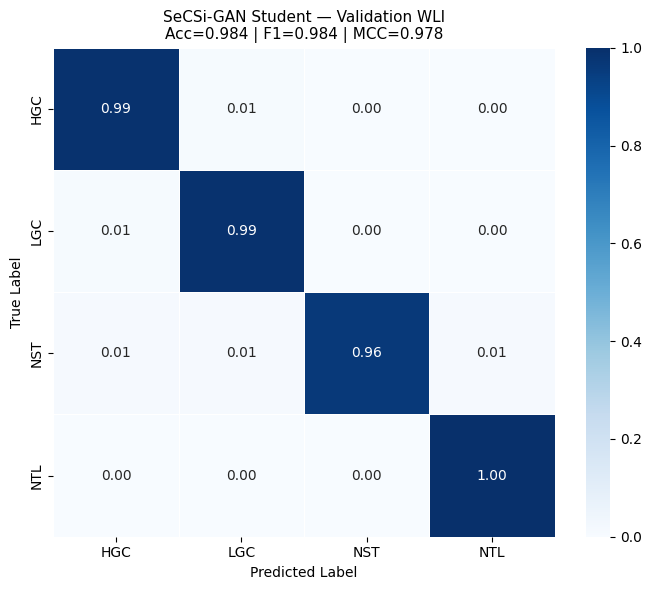


EVALUATION: Test WLI
              precision    recall  f1-score   support

         HGC     0.8333    0.6250    0.7143         8
         LGC     1.0000    0.9714    0.9855        70
         NST     0.8800    1.0000    0.9362        44
         NTL     0.5714    0.4444    0.5000         9

    accuracy                         0.9237       131
   macro avg     0.8212    0.7602    0.7840       131
weighted avg     0.9201    0.9237    0.9190       131

Accuracy        : 0.9237
Precision (wtd) : 0.9201
Recall (wtd)    : 0.9237
F1 (wtd)        : 0.9190
MCC             : 0.8723
Cohen's Kappa   : 0.8702


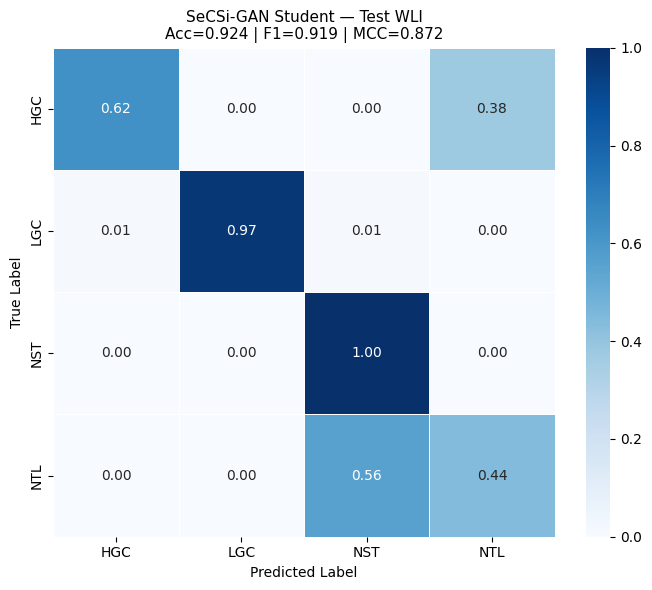

In [12]:
# ============================================================
# EVALUATION
# Accuracy, Precision, Recall, F1, MCC, Cohen's Kappa
# Evaluated separately on WLI test and NBI test (Table VI)
# ============================================================

def full_evaluation(model, dataset, class_names, split_name):
    y_true_all = []
    y_pred_all = []
    y_prob_all = []

    for inputs, labels in dataset:
        probs = model.predict(inputs, verbose=0)
        y_true_all.extend(np.argmax(labels.numpy(), axis=1))
        y_pred_all.extend(np.argmax(probs, axis=1))
        y_prob_all.extend(probs)

    y_true = np.array(y_true_all)
    y_pred = np.array(y_pred_all)

    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4,
        output_dict=True
    )

    acc   = report['accuracy']
    prec  = report['weighted avg']['precision']
    rec   = report['weighted avg']['recall']
    f1    = report['weighted avg']['f1-score']
    mcc   = matthews_corrcoef(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    print(f"\n{'='*55}")
    print(f"EVALUATION: {split_name}")
    print(f"{'='*55}")
    print(classification_report(
        y_true, y_pred, target_names=class_names, digits=4))
    print(f"Accuracy        : {acc:.4f}")
    print(f"Precision (wtd) : {prec:.4f}")
    print(f"Recall (wtd)    : {rec:.4f}")
    print(f"F1 (wtd)        : {f1:.4f}")
    print(f"MCC             : {mcc:.4f}")
    print(f"Cohen's Kappa   : {kappa:.4f}")

    # Normalized confusion matrix (matches paper Fig. 6)
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax, linewidths=0.5,
        vmin=0, vmax=1
    )
    ax.set_title(
        f'SeCSi-GAN Student — {split_name}\n'
        f'Acc={acc:.3f} | F1={f1:.3f} | MCC={mcc:.3f}',
        fontsize=11
    )
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    fname = f"student_cm_{split_name.lower().replace(' ', '_')}.png"
    plt.savefig(
        os.path.join(CFG.OUTPUT_PATH, fname),
        dpi=150, bbox_inches='tight'
    )
    plt.show()

    return {
        'accuracy':  acc,
        'precision': prec,
        'recall':    rec,
        'f1':        f1,
        'mcc':       mcc,
        'kappa':     kappa,
    }

# Load best weights before evaluation
student_model.load_weights(
    os.path.join(CFG.OUTPUT_PATH, "student_best.weights.h5")
)
print("Loaded best weights for evaluation.")

# Evaluate on all splits
val_results      = full_evaluation(student_model, val_ds,      CFG.CLASS_NAMES, "Validation WLI")
test_wli_results = full_evaluation(student_model, test_wli_ds, CFG.CLASS_NAMES, "Test WLI")
if test_nbi_triplets:
    test_nbi_results = full_evaluation(student_model, test_nbi_ds, CFG.CLASS_NAMES, "Test NBI")

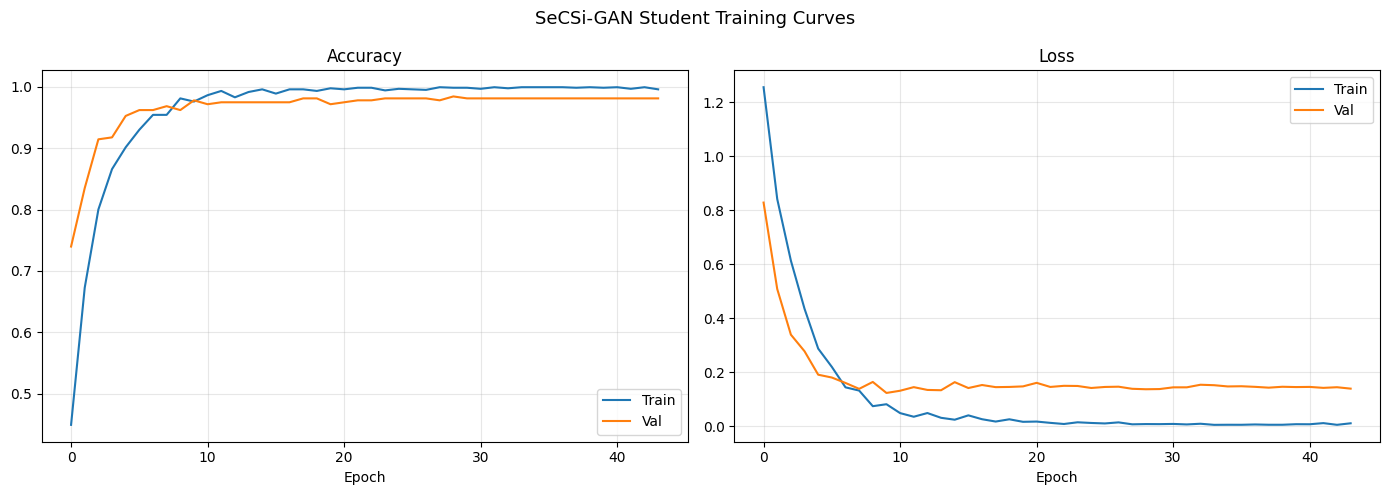

In [13]:
# ============================================================
# TRAINING CURVES
# ============================================================

log_df = pd.read_csv(
    os.path.join(CFG.OUTPUT_PATH, "student_training_log.csv")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SeCSi-GAN Student Training Curves', fontsize=13)

axes[0].plot(log_df['epoch'], log_df['accuracy'],     label='Train')
axes[0].plot(log_df['epoch'], log_df['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(log_df['epoch'], log_df['loss'],     label='Train')
axes[1].plot(log_df['epoch'], log_df['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(CFG.OUTPUT_PATH, "student_training_curves.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()

In [14]:
# ============================================================
# SAVE FINAL SUMMARY
# ============================================================

summary = {
    'val_accuracy':      float(val_results['accuracy']),
    'val_f1':            float(val_results['f1']),
    'val_mcc':           float(val_results['mcc']),
    'val_kappa':         float(val_results['kappa']),
    'test_wli_accuracy': float(test_wli_results['accuracy']),
    'test_wli_f1':       float(test_wli_results['f1']),
    'test_wli_mcc':      float(test_wli_results['mcc']),
    'test_wli_kappa':    float(test_wli_results['kappa']),
}
if test_nbi_triplets:
    summary.update({
        'test_nbi_accuracy': float(test_nbi_results['accuracy']),
        'test_nbi_f1':       float(test_nbi_results['f1']),
        'test_nbi_mcc':      float(test_nbi_results['mcc']),
        'test_nbi_kappa':    float(test_nbi_results['kappa']),
    })

with open(os.path.join(CFG.OUTPUT_PATH, "student_summary.json"), 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*55)
print("NOTEBOOK 3 COMPLETE")
print("="*55)
print(f"\nKey results:")
print(f"  Val  Accuracy : {val_results['accuracy']:.4f}")
print(f"  Val  F1       : {val_results['f1']:.4f}")
print(f"  Test Accuracy : {test_wli_results['accuracy']:.4f}")
print(f"  Test F1       : {test_wli_results['f1']:.4f}")
print(f"  Test MCC      : {test_wli_results['mcc']:.4f}")
print(f"  Test Kappa    : {test_wli_results['kappa']:.4f}")


NOTEBOOK 3 COMPLETE

Key results:
  Val  Accuracy : 0.9841
  Val  F1       : 0.9841
  Test Accuracy : 0.9237
  Test F1       : 0.9190
  Test MCC      : 0.8723
  Test Kappa    : 0.8702
